In [42]:
%load_ext autoreload
%autoreload 2

import polars as pl
import matplotlib.pyplot as plt
from data.loader import load_bindingdb_data
from data.transform import (
    remove_nulls,
    tranform_ki_to_log_ki,
    train_test_val_split,
    create_pyg_dataset,
    remove_cx_notation,
    tokenize_sequences,
    remove_duplicates
)
from datasets.models import ProteinLigandDataset
from torch_geometric.data import Batch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df = load_bindingdb_data()
df.head()

Ligand SMILES,Full_Protein_Sequence,Ki (nM),n_chains
str,str,f64,i32
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.24,1
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.25,1
"""O[C@@H]1[C@@H](O)[C@@H](Cc2ccc…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.41,1
"""OCCCCCCN1[C@H](Cc2ccccc2)[C@H]…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.8,1
"""OCCCCCN1[C@H](Cc2ccccc2)[C@H](…","""PQITLWQRPLVTIKIGGQLKEALLDTGADD…",0.99,1


In [3]:
def analyze_weird_smiles(df, col_name="Ligand SMILES"):
    weird_df = df.filter(pl.col(col_name).str.contains(r"\|"))

    total_records = df.height
    weird_count = weird_df.height
    percentage = (weird_count / total_records) * 100

    unique_weird = weird_df.select(col_name).unique()

    print("--- Analiza formatu CXSMILES ---")
    print(f"Suma wszystkich rekordów: {total_records}")
    print(f"Liczba rekordów z '|...|': {weird_count} ({percentage:.2f}%)")
    print(f"Liczba unikalnych struktur z tym zapisem: {unique_weird.height}")
    print("-" * 32)

    if weird_count > 0:
        print("Przykładowe smilesy z dziwnym zapisem:")
        for s in unique_weird.head(5).to_series():
            print(f"-> {s}")
    else:
        print("Nie znaleziono żadnych rekordów z tym formatem.")

    return unique_weird


weird_smiles_list = analyze_weird_smiles(df)

--- Analiza formatu CXSMILES ---
Suma wszystkich rekordów: 574309
Liczba rekordów z '|...|': 165167 (28.76%)
Liczba unikalnych struktur z tym zapisem: 73876
--------------------------------
Przykładowe smilesy z dziwnym zapisem:
-> C[C@@H]1NC(CS1)\C=C\c1nc2ccccc2c(=O)n1-c1cccnc1C |r,wU:1.0,(16.26,-2.66,;14.78,-3.06,;13.53,-2.16,;12.28,-3.06,;12.76,-4.52,;14.3,-4.52,;11.08,-2.44,;11.08,-.9,;9.75,-.13,;8.41,-.9,;7.08,-.13,;5.75,-.9,;4.41,-.13,;4.41,1.41,;5.75,2.18,;7.08,1.41,;8.41,2.18,;8.41,3.72,;9.75,1.41,;11.08,2.18,;12.42,1.41,;13.75,2.18,;13.75,3.72,;12.42,4.49,;11.08,3.72,;9.75,4.49,)|
-> Cl.CCCN1CCC[C@@H](C1)c1ccc(C)c(C)c1 |r|
-> CC[C@H](NC(=O)CCc1ccc(cc1)-c1cccc(c1)[N+]([O-])=O)C(=O)N[C@@H](CCC(O)=O)C(N)=O |r|
-> OC[C@@H](OCC(=O)NO)c1ccc(cc1)C#Cc1ccccc1 |r|
-> CCCCC[C@H](O)\C=C\[C@H]1C2OC2C(=O)[C@@H]1C\C=C/CCCC(O)=O |r|


In [4]:
df = remove_cx_notation(df)
analyze_weird_smiles(df)

--- Analiza formatu CXSMILES ---
Suma wszystkich rekordów: 574309
Liczba rekordów z '|...|': 0 (0.00%)
Liczba unikalnych struktur z tym zapisem: 0
--------------------------------
Nie znaleziono żadnych rekordów z tym formatem.


Ligand SMILES
str


In [5]:
df["Ki (nM)"].describe()

statistic,value
str,f64
"""count""",574309.0
"""null_count""",0.0
"""mean""",342584.802058
"""std""",1.1899e7
"""min""",0.000006
"""25%""",8.7
"""50%""",100.0
"""75%""",1500.0
"""max""",4.0000e9


In [6]:
df = remove_nulls(df)
df = remove_duplicates(df)
df = tranform_ki_to_log_ki(df)
df["pKi"].describe()

statistic,value
str,f64
"""count""",451913.0
"""null_count""",0.0
"""mean""",6.869246
"""std""",1.516418
"""min""",4.0
"""25%""",5.721246
"""50%""",6.89279
"""75%""",8.0
"""max""",14.0


In [7]:
df = df.with_columns([(pl.col("pKi") >= 7).alias("is_active")])
df["is_active"].value_counts()

is_active,count
bool,u32
true,216979
false,234934


In [8]:
VOCAB_SEQUENCE = set("".join(df["Full_Protein_Sequence"].str.to_uppercase().to_list()))
VOCAB_SIZE = len(VOCAB_SEQUENCE)
char_to_idx = {char: idx for idx, char in enumerate(sorted(VOCAB_SEQUENCE))}
df = tokenize_sequences(df, char_to_idx)

In [9]:
train_df, val_df, test_df = train_test_val_split(df)
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)
train_df["Ligand SMILES"]

(315011, 6)
(45338, 6)
(91564, 6)


Ligand SMILES
str
"""Cc1ccc(cn1)-c1ccc2ncc3n(C)c(=O…"
"""NS(=O)(=O)c1ccc(cc1)C(=O)N1CCN…"
"""Cn1cc(Br)c(n1)C(=O)N1CCN(CC(O)…"
"""CCCCCCCCCCCCCCOC(=O)CC[C@]1(CO…"
"""CC(=O)Nc1ccc(OCCCN2CCN(CC2)c2c…"
…
"""NS(=O)(=O)c1ccc(CN2C(=O)C3C(C2…"
"""C[C@H](Oc1cccc(Cl)c1Cl)C(=O)Nc…"
"""CCCNC(=O)[C@H](CC(C)C)NC(=O)[C…"


In [13]:
all_unique_smiles = df["Ligand SMILES"].unique().to_list()

all_graphs = create_pyg_dataset(all_unique_smiles, with_features=True)
global_smiles_map = dict(zip(all_unique_smiles, all_graphs))

Konwersja 236422 SMILES na grafy (with_features=True)...


317it [00:01, 212.05it/s][16:06:52] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 30 31
372it [00:01, 233.99it/s]

'NoneType' object has no attribute 'GetAtoms'


633it [00:02, 242.15it/s][16:06:53] Explicit valence for atom # 14 O, 3, is greater than permitted
658it [00:02, 234.06it/s]

'NoneType' object has no attribute 'GetAtoms'


...

227995it [26:55, 249.33it/s][16:33:46] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
228046it [26:55, 239.60it/s]

'NoneType' object has no attribute 'GetAtoms'


235955it [27:22, 297.28it/s][16:34:13] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 29 30 31
236016it [27:22, 292.73it/s]

'NoneType' object has no attribute 'GetAtoms'


236422it [27:24, 143.79it/s]


In [14]:
valid_keys = set(global_smiles_map.keys())
print(f"Liczba poprawnych grafów w słowniku: {len(valid_keys)}")

train_df = train_df.filter(pl.col("Ligand SMILES").is_in(valid_keys))
val_df = val_df.filter(pl.col("Ligand SMILES").is_in(valid_keys))
test_df = test_df.filter(pl.col("Ligand SMILES").is_in(valid_keys))

print(f"Rekordy w treningu po synchronizacji: {train_df.height}")
print(f"Rekordy w walidacji po synchronizacji: {val_df.height}")
print(f"Rekordy w teście po synchronizacji: {test_df.height}")

Liczba poprawnych grafów w słowniku: 236379
Rekordy w treningu po synchronizacji: 314956
Rekordy w walidacji po synchronizacji: 45332
Rekordy w teście po synchronizacji: 91545


In [50]:
train_dataset = ProteinLigandDataset(train_df, global_smiles_map)
assert (
    len(train_dataset.smiles) == len(train_dataset.sequences) == len(train_dataset.labels)
), "Rozsynchronizowane listy — prawdopodobnie błędne SMILES!"
test_dataset = ProteinLigandDataset(test_df, global_smiles_map)
assert (
    len(test_dataset.smiles) == len(test_dataset.sequences) == len(test_dataset.labels)
), "Rozsynchronizowane listy — prawdopodobnie błędne SMILES!"

val_dataset = ProteinLigandDataset(val_df, global_smiles_map)
assert (
    len(val_dataset.smiles) == len(val_dataset.sequences) == len(val_dataset.labels)
), "Rozsynchronizowane listy — prawdopodobnie błędne SMILES!"

In [51]:
from torch_geometric.nn import global_add_pool
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from ogb.graphproppred.mol_encoder import AtomEncoder

class ProteinLigandModel(nn.Module):
    def __init__(self, vocab_size, gcn_hidden=256, cnn_filters=128, embed_dim=256, dropout=0.3):
        super().__init__()

        # --- Gałąź GCN (dla SMILES) ---
        self.atom_encoder = AtomEncoder(emb_dim=gcn_hidden)
        self.gcn_convs = nn.ModuleList([GCNConv(gcn_hidden, gcn_hidden) for _ in range(3)])
        self.gcn_bns = nn.ModuleList([nn.BatchNorm1d(gcn_hidden) for _ in range(3)])

        # --- Gałąź CNN (dla sekwencji) ---
        self.seq_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv3 = self._conv_block(embed_dim, cnn_filters, kernel=3)
        self.conv7 = self._conv_block(embed_dim, cnn_filters, kernel=7)
        self.conv15 = self._conv_block(embed_dim, cnn_filters, kernel=15)

        # --- Klasyfikator (łączy obie gałęzie) ---
        combined_dim = gcn_hidden + 3 * cnn_filters
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def _conv_block(self, in_ch, out_ch, kernel):
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
        )

    def _masked_pool(self, x, mask):
        x = x.masked_fill(mask == 0, float("-inf"))
        return x.max(dim=2).values

    def forward(self, graph_batch, seq_batch):
        # --- GCN ---
        x = self.atom_encoder(graph_batch.x)
        for conv, bn in zip(self.gcn_convs, self.gcn_bns):
            x = F.leaky_relu(bn(conv(x, graph_batch.edge_index)))
        graph_emb = global_add_pool(x, graph_batch.batch)  # (B, gcn_hidden)

        # --- CNN ---
        mask = (seq_batch != 0).unsqueeze(1).float()
        s = self.seq_embedding(seq_batch).transpose(1, 2)
        out3 = self._masked_pool(self.conv3(s), mask)
        out7 = self._masked_pool(self.conv7(s), mask)
        out15 = self._masked_pool(self.conv15(s), mask)
        seq_emb = torch.cat([out3, out7, out15], dim=1)  # (B, 3*cnn_filters)

        # --- Połączenie i klasyfikacja ---
        combined = torch.cat([graph_emb, seq_emb], dim=1)  # (B, gcn_hidden + 3*cnn_filters)
        return self.classifier(combined)

In [52]:
from tqdm import tqdm


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Train", leave=False)
    for graph_batch, seq_batch, y in pbar:
        graph_batch = graph_batch.to(device)
        seq_batch = seq_batch.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(graph_batch, seq_batch).squeeze(1)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [53]:
from torch_geometric.data import Data

def collate_fn(batch):
    graphs, seqs, labels = zip(*batch)

    pyg_graphs  = [Data(x=g["x"], edge_index=g["edge_index"], edge_attr=g["edge_attr"]) for g in graphs]
    graph_batch = Batch.from_data_list(pyg_graphs)
    seq_batch   = pad_sequence(seqs, batch_first=True, padding_value=0)
    label_batch = torch.stack(labels)

    return graph_batch, seq_batch, label_batch

In [60]:
model = ProteinLigandModel(vocab_size=len(char_to_idx) + 1)
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ProteinLigandModel(
  (atom_encoder): AtomEncoder(
    (atom_embedding_list): ModuleList(
      (0): Embedding(119, 256)
      (1): Embedding(5, 256)
      (2-3): 2 x Embedding(12, 256)
      (4): Embedding(10, 256)
      (5-6): 2 x Embedding(6, 256)
      (7-8): 2 x Embedding(2, 256)
    )
  )
  (gcn_convs): ModuleList(
    (0-2): 3 x GCNConv(256, 256)
  )
  (gcn_bns): ModuleList(
    (0-2): 3 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (seq_embedding): Embedding(21, 256, padding_idx=0)
  (conv3): Sequential(
    (0): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (conv7): Sequential(
    (0): Conv1d(256, 128, kernel_size=(7,), stride=(1,), p

In [ ]:
@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc="Val  ", leave=False)
    for graph_batch, seq_batch, y in pbar:
        graph_batch = graph_batch.to(device)
        seq_batch = seq_batch.to(device)
        y = y.to(device)

        logits = model(graph_batch, seq_batch).squeeze(1)
        total_loss += criterion(logits, y).item()

        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    all_preds = (np.array(all_probs) > 0.5).astype(int)

    metrics = {
        "loss": total_loss / len(loader),
        "auc": roc_auc_score(all_labels, all_probs),
        "auprc": average_precision_score(all_labels, all_probs), 
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
    }
    return metrics

In [62]:
from sklearn.metrics import roc_auc_score

import warnings

# warnings.filterwarnings("ignore", module="torch.utils.data.dataloader")


def train_loop(model, train_loader, val_loader, optimizer, criterion, device, epochs=50):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_val_auc = 0
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        # --- Trening ---
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)

        # --- Walidacja ---
        metrics = eval_epoch(model, val_loader, criterion, device)
        val_loss, val_auc = metrics["loss"], metrics["auc"]
        scheduler.step(val_loss)

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f}")

        # --- Zapis najlepszego modelu ---
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch
            torch.save(model.state_dict(), "best_model.pt")
            print(f"  ✓ Nowy najlepszy model (epoch {epoch}, val_auc={val_auc:.4f})")

        # --- Early stopping ---
        if epoch - best_epoch >= 8:
            print(f"Early stopping — brak poprawy od {15} epok")
            break

    print(f"\nNajlepszy model: epoch {best_epoch}, val_auc={best_val_auc:.4f}")

    # --- Załaduj najlepszy model i oceń na teście ---
    model.load_state_dict(torch.load("best_model.pt"))
    return model


# Uruchomienie
model = train_loop(model, train_loader, val_loader, optimizer, criterion, device, epochs=50)

Epoch 001 | train_loss=0.6182 | val_loss=0.5992 | val_auc=0.7328
  ✓ Nowy najlepszy model (epoch 1, val_auc=0.7328)


Epoch 002 | train_loss=0.5978 | val_loss=0.5937 | val_auc=0.7388
  ✓ Nowy najlepszy model (epoch 2, val_auc=0.7388)


Epoch 003 | train_loss=0.5929 | val_loss=0.5908 | val_auc=0.7417
  ✓ Nowy najlepszy model (epoch 3, val_auc=0.7417)


Epoch 004 | train_loss=0.5905 | val_loss=0.5919 | val_auc=0.7406


Epoch 005 | train_loss=0.5880 | val_loss=0.5899 | val_auc=0.7427
  ✓ Nowy najlepszy model (epoch 5, val_auc=0.7427)


...

Epoch 018 | train_loss=0.5780 | val_loss=0.5854 | val_auc=0.7472


Epoch 019 | train_loss=0.5771 | val_loss=0.5855 | val_auc=0.7461


Epoch 020 | train_loss=0.5767 | val_loss=0.5860 | val_auc=0.7458


Epoch 021 | train_loss=0.5732 | val_loss=0.5848 | val_auc=0.7468


Epoch 022 | train_loss=0.5717 | val_loss=0.5857 | val_auc=0.7465
Early stopping — brak poprawy od 15 epok

Najlepszy model: epoch 14, val_auc=0.7477


In [65]:
# Ewaluacja na zbiorze testowym
val_metrics = eval_epoch(model, test_loader, criterion, device)
print(
    f"val_loss={val_metrics['loss']:.4f} | "
    f"auc={val_metrics['auc']:.4f} | "
    f"auprc={val_metrics['auprc']:.4f} | "
    f"f1={val_metrics['f1']:.4f} | "
    f"precision={val_metrics['precision']:.4f} | "
    f"recall={val_metrics['recall']:.4f}"
)

Val  :   0%|          | 0/358 [00:00<?, ?it/s]

val_loss=0.5864 | auc=0.7459 | auprc=0.7325 | f1=0.6546 | precision=0.6669 | recall=0.6428


Confusion matrix:   0%|          | 0/358 [00:00<?, ?it/s]

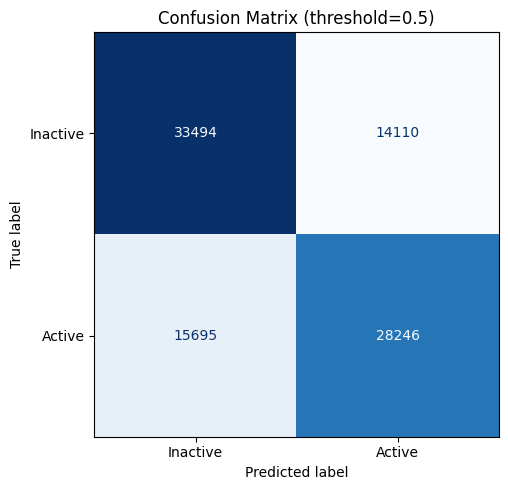

TP=28246 | FP=14110 | FN=15695 | TN=33494
Sensitivity (recall) = 0.6428
Specificity          = 0.7036
Precision            = 0.6669


In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def plot_confusion_matrix(model, loader, device, threshold=0.5):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for graph_batch, seq_batch, y in tqdm(loader, desc="Confusion matrix", leave=False):
            graph_batch = graph_batch.to(device)
            seq_batch = seq_batch.to(device)

            logits = model(graph_batch, seq_batch).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_preds.extend((probs > threshold).astype(int))
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Inactive", "Active"])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix (threshold={threshold})")
    plt.tight_layout()
    plt.show()

    # Czytelne podsumowanie tekstowe
    tn, fp, fn, tp = cm.ravel()
    print(f"TP={tp} | FP={fp} | FN={fn} | TN={tn}")
    print(f"Sensitivity (recall) = {tp / (tp + fn):.4f}")
    print(f"Specificity          = {tn / (tn + fp):.4f}")
    print(f"Precision            = {tp / (tp + fp):.4f}")


plot_confusion_matrix(model, test_loader, device)